In [ ]:
# Imports
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# Read data
df = pd.read_csv('LassoFeatures2_PlanetNames.csv')
df = df.drop('Unnamed: 0',axis=1)

In [115]:
#Split data & define features/targets
(df_train,df_test) = train_test_split(df,train_size=0.8,
                                      test_size=0.2,
                                      random_state=0)
X_train = df_train.drop(['log radius', 'planet_name'],axis=1)
X_test  = df_test.drop(['log radius', 'planet_name'],axis=1)
y_train   = df_train['log radius']
y_test    = df_test['log radius']
names_train = df_train['planet_name']
names_test = df_test['planet_name']

In [ ]:
# Make and train best model
rf = RandomForestRegressor(max_depth = 17,n_estimators=501,max_features = 1/3,oob_score=True)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",501
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",17
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.3333333333333333
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the nu

In [ ]:
# Predict based on regressor
y_pred = rf.predict(X_test)

In [ ]:
# Make dataframe for easy lookups
df = pd.DataFrame()
df['names'] = names_test.values
df['pred'] = 10**y_pred
df['actual'] = 10**y_test.values
df['relErr'] = np.abs(10**(y_pred) - 10**y_test.values) / 10**y_test.values

In [ ]:
# Stats of worst error prediction
df.loc[df.idxmax()["relErr"]]

names     Kepler-1603 b
pred           3.826166
actual             1.29
relErr          1.96602
Name: 73, dtype: object

In [ ]:
# Stats of best error prediction
df.loc[df.idxmin()["relErr"]]

names     Kepler-1540 b
pred           2.488754
actual             2.49
relErr         0.000501
Name: 164, dtype: object

In [ ]:
# Shape
df.shape

(358, 4)

In [ ]:
# Stats of input index
df.loc[57]

names     Kepler-791 b
pred          2.335795
actual            3.05
relErr        0.234166
Name: 57, dtype: object

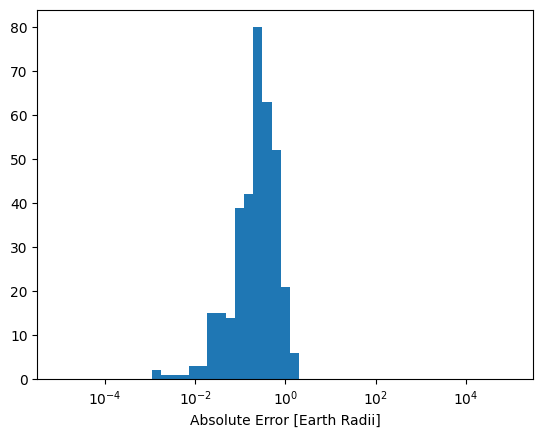

In [ ]:
# Err plot 1
plt.figure()
plt.hist(df['relErr'], bins=np.logspace(-5,5))
plt.xscale("log")
plt.xlabel("Absolute Error [Earth Radii]")
plt.show()


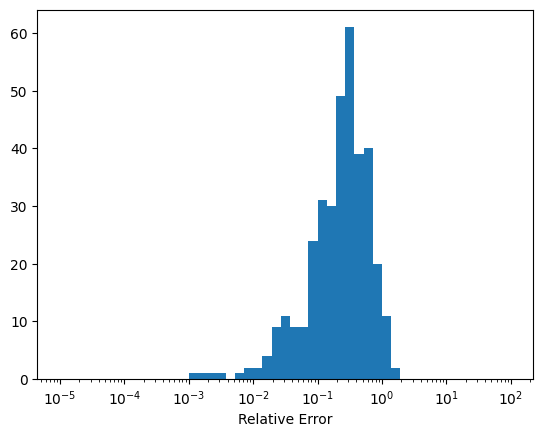

In [ ]:
# Err plot 2
plt.figure()
plt.hist(df['relErr'], bins=np.logspace(-5,2))
plt.xscale("log")
plt.xlabel("Relative Error")
plt.show()
